In [1]:
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import *
from plotting import *
from get_LrLx_data import *

In [2]:
all_xray_df, all_radio_df, Lr_med, Lx_med = get_all_data()

Found 26 data files.
1A 1744-361: Distance [kpc] = 8.0
4U 1543-47: Distance [kpc] = 5.0
4U 1630-47: Distance [kpc] = 11.5
Cen X-4: Distance [kpc] = 1.87
Cir X-1: Distance [kpc] = 9.4
EXO 1846-031: Distance [kpc] = 4.5
GRS 1739-278: Distance [kpc] = 8
GRS 1915+105: Distance [kpc] = 9.4
GX 339-4: Distance [kpc] = 10.0
H1743-322: Distance [kpc] = 8.5
IGR J17091-3624: Distance [kpc] = 14.0
MAXI J1348-630: Distance [kpc] = 2.2
MAXI J1631-479: Distance [kpc] = 5.1
MAXI J1803-298: Distance [kpc] = 8.0
MAXI J1807+132: Distance [kpc] = 6.3
MAXI J1810-222: Distance [kpc] = 8.0
MAXI J1816-195: Distance [kpc] = 6.0
MAXI J1820+070: Distance [kpc] = 2.96
SAX J1808.4-3658: Distance [kpc] = 2.7
SAX J1810.8-2609: Distance [kpc] = 4.9
Swift J1727.8-1613: Distance [kpc] = 5.5
Swift J1728.9-3613: Distance [kpc] = 8.4
Swift J1842.5-1124: Distance [kpc] = 8.12
Swift J1858.6-0814: Distance [kpc] = 12.8
Vela X-1: Distance [kpc] = 1.99
XTE J1701-462: Distance [kpc] = 8.8
Median Lr (HS/QS detections): 4.52e+28 

In [102]:
def plot_all_lightcurves(xray_df, radio_df, log=True, show_errorbars=False,
                         highlight_name=None, save_name=None):
    """
    Plot:
        - X-ray flux (top)
        - Radio flux density (bottom)
        - Shared x-axis
    Also creates a separate luminosity figure (same as before).
    """

    # ---------------------------
    # Create figures
    # ---------------------------
    fig_flux, (ax_xray_flux, ax_radio_flux) = plt.subplots(
        2, 1, figsize=(14, 7.875), sharex=True, gridspec_kw={'hspace': 0}
    )

    names = np.unique(np.concatenate([
        xray_df["name"].unique(),
        radio_df["name"].unique()
    ]))

    source_classes = np.full(len(names), '', dtype='U20')

    # ==========================================================
    # ===================== X-RAY SECTION ======================
    # ==========================================================
    for i, name in enumerate(names):

        if name == "GX 339-4":
            zorder = 5
        elif name == highlight_name:
            zorder = 4
        else:
            zorder = 1

        if highlight_name and name != highlight_name:
            c = "grey"
        else:
            c = colours.get(name, "black")

        filtered = xray_df[xray_df["name"] == name]
        if len(filtered)==0: continue
        source_class = filtered["class"].iloc[0]
        source_classes[i] = source_class

        MJDs = filtered["t_xray"].to_numpy()
        states = filtered["Xstate"].to_numpy()
        uplims = filtered["Fx_uplim_bool"].to_numpy()

        F = filtered["Fx"].to_numpy()
        F_unc_l = filtered["Fx_unc_l"].to_numpy()
        F_unc_u = filtered["Fx_unc_u"].to_numpy()

        L = filtered["Lx"].to_numpy()
        L_unc_l = filtered["Lx_unc_l"].to_numpy()
        L_unc_u = filtered["Lx_unc_u"].to_numpy()

        dates = Time(MJDs, format="mjd").datetime

        if not show_errorbars:
            F_unc_l[~uplims] = 0
            F_unc_u[:] = 0
            L_unc_l[~uplims] = 0
            L_unc_u[:] = 0

        # Upper limit arrows
        F_unc_l[uplims] = F[uplims] / 3
        F_unc_u[uplims] = 0
        L_unc_l[uplims] = L[uplims] / 3
        L_unc_u[uplims] = 0

        for state in np.unique(states):
            mask = states == state
            marker = state_markers.get(state, ".")
            ms = state_markersizes_large.get(state, 3)

            # --- X-ray flux (TOP PANEL) ---
            ax_xray_flux.errorbar(
                dates[mask], F[mask],
                yerr=[F_unc_l[mask], F_unc_u[mask]],
                fmt=marker, ms=ms, color=c,
                uplims=uplims[mask],
                ecolor="black", elinewidth=0.4,
                capsize=0.9, zorder=zorder
            )

    # ==========================================================
    # ===================== RADIO SECTION ======================
    # ==========================================================
    for i, name in enumerate(names):

        if name == "GX 339-4":
            zorder = 5
        elif name == highlight_name:
            zorder = 4
        else:
            zorder = 1

        if highlight_name and name != highlight_name:
            c = "grey"
        else:
            c = colours.get(name, "black")

        filtered = radio_df[radio_df["name"] == name]
        if len(filtered)==0: continue

        source_class = filtered["class"].iloc[0]
        source_classes[i] = source_class

        MJDs = filtered["t_radio"].to_numpy()
        states = filtered["Rstate"].to_numpy()
        uplims = filtered["Fr_uplim_bool"].to_numpy()

        F = filtered["Fr"].to_numpy()
        F_unc = filtered["Fr_unc"].to_numpy().copy()

        dates = Time(MJDs, format="mjd").datetime

        if not show_errorbars:
            F_unc[~uplims] = 0

        F_unc[uplims] = F[uplims] / 3

        for state in np.unique(states):
            mask = states == state
            marker = state_markers.get(state, ".")
            ms = state_markersizes_large.get(state, 3)

            # --- Radio flux (BOTTOM PANEL) ---
            ax_radio_flux.errorbar(
                dates[mask], F[mask],
                yerr=F_unc[mask],
                fmt=marker, ms=ms, color=c,
                uplims=uplims[mask],
                ecolor="black", elinewidth=0.4,
                capsize=0.9, zorder=zorder
            )


    ax_xray_flux.axhline(3e-12, linestyle='--', color="grey", linewidth=2)

    # ==========================================================
    # ===================== FORMATTING =========================
    # ==========================================================

    if log:
        ax_xray_flux.set_yscale("log")
        ax_radio_flux.set_yscale("log")

    ax_xray_flux.set_ylabel(
        "1–10 keV Unabsorbed X-ray Flux\n"+ r"[erg s$^{-1}$ cm$^{-2}$]", fontsize=12
    )
    ax_radio_flux.set_ylabel("1.28 GHz Radio Flux Density \n[mJy]", fontsize=12)

    # Shared x-axis formatting
    all_mjd = np.concatenate([
        xray_df["t_xray"].to_numpy(),
        radio_df["t_radio"].to_numpy()
    ])

    min_mjd = np.floor(np.min(all_mjd) / 10) * 10
    max_mjd = np.max(all_mjd)

    FormatAxis_new(
        [ax_xray_flux, ax_radio_flux],
        start_mjd=min_mjd - 20,
        end_mjd=max_mjd + 20,
        interval=200
    )


    # ----- Source legend ----- (rebuild handles)
    names_text = [name.replace("-", "–") for name in names]
    source_classes = ["BHc" if sc == "candidateBH" else sc for sc in source_classes]

    if highlight_name:
        source_legend_handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color=colours.get(name, 'grey') if name == highlight_name else 'grey',
                linestyle='None',
                markersize=8,
                label=f"{name_text} ({source_class})"
            )
            for (name, name_text, source_class)
            in zip(names, names_text, source_classes)
        ]
    else:
        source_legend_handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color=colours.get(name, 'black'),
                linestyle='None',
                markersize=8,
                label=f"{name_text} ({source_class})"
            )
            for (name, name_text, source_class)
            in zip(names, names_text, source_classes)
        ]

    # ----- State legend (attached to the top axis, upper right) -----
    state_legend_handles = [
        plt.Line2D([0], [0], marker=marker, color='black', linestyle='None', markersize=6, label=state)
        for state, marker in state_markers.items()
    ]
    # attach state legend to the top-right of the top panel (axes-level)
    ax_radio_flux.legend(handles=state_legend_handles, loc="upper right", title="States", fontsize=9)
    # if you also want the legend box to have a white background and slight transparency:
    # state_legend = ax_xray_flux.legend(handles=state_legend_handles, loc="upper right", title="States", fontsize=10)
    # state_legend.get_frame().set_alpha(0.9)

    # ----- Figure-level source legend below both panels -----
    # Make space for the legend under both panels (bottom must be small enough to leave room)
    fig_flux.subplots_adjust(hspace=0, bottom=0.18)  # <- bottom ~0.18 works well for fig figsize=(14,7.875)

    # Place the legend for the whole figure just below the axes (figure coordinates)
    fig_legend = fig_flux.legend(
        handles=source_legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.045),   # y slightly below the axes region
        ncol= 5, 
        title="Sources",
        columnspacing=0.4,
        handletextpad=0.05,
        labelspacing=0.1,
        borderpad=0.2, fontsize=11
    )


    # ----- Save (include the figure legend in bbox_extra_artists to avoid clipping) -----
    if save_name:
        # include fig_legend in bbox_extra_artists so bbox_inches='tight' doesn't cut it off
        fig_flux.savefig(f"../FIGURES/{save_name}_flux_combined.png",
                         dpi=300, bbox_inches='tight', bbox_extra_artists=[fig_legend])
        fig_flux.savefig(f"../FIGURES/{save_name}_flux_combined.pdf",
                         dpi=300, bbox_inches='tight', bbox_extra_artists=[fig_legend])

    plt.show()

c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 2 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


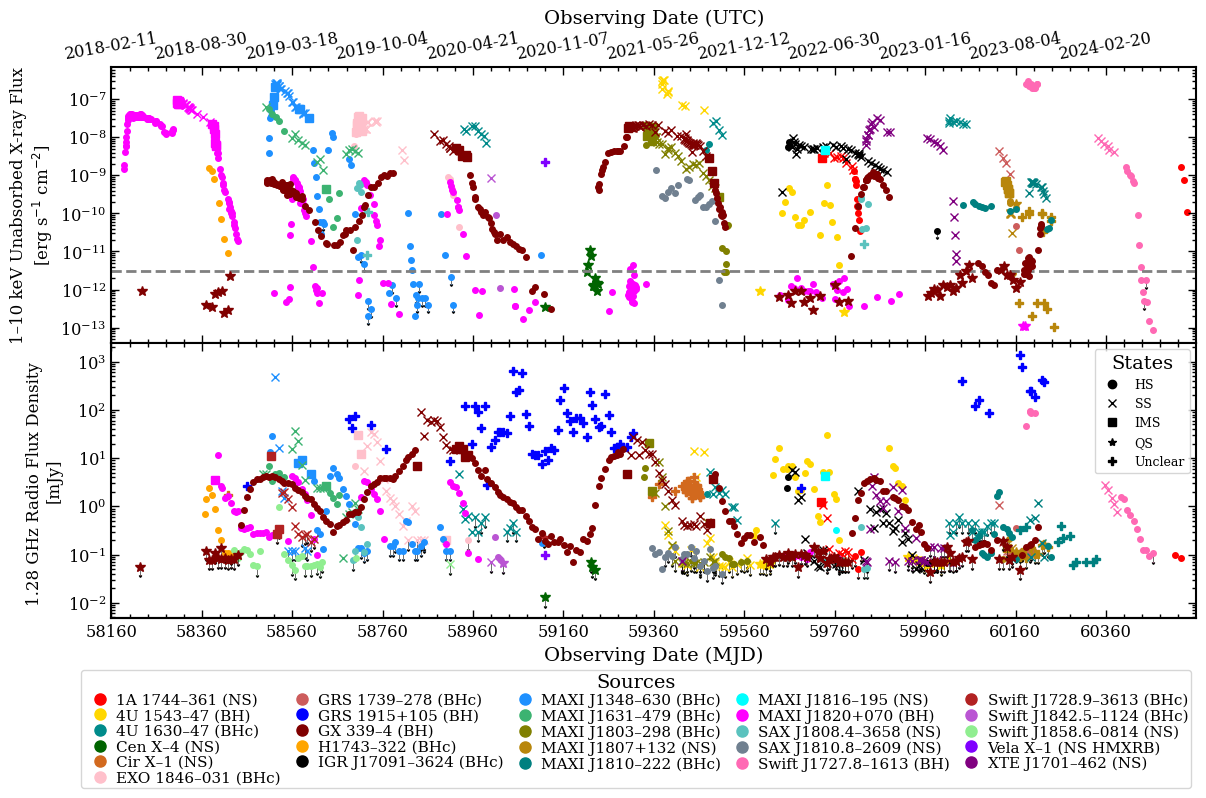

In [103]:
plot_all_lightcurves(all_xray_df, all_radio_df, log=True, show_errorbars=False, highlight_name=None, save_name="proposal")